In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits
import healpy as hp
import yaml

from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
nmad = lambda x: 1.4826 * np.median(np.abs(x-np.median(x)))

In [4]:
min_nobs = 2
max_ebv = 0.15
max_stardens = 2500

In [5]:
main_dir = '/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.1.1/resolve'
tmp = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/dr9_lrg_1.1.1_pzbins_20221204.fits'))
tmp1 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/dr9_lrg_1.1.1_pzbins_20221204-weights.fits'))
lrg = hstack([tmp, tmp1], join_type='exact')

In [6]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/ls_dr9.0_photoz/misc/lss_daily_y1_lrg_full_noveto_20221031.fits'))
print(len(cat), len(np.unique(cat['TARGETID'])))

cat = join(cat, lrg[['TARGETID', 'PIXEL_NOBS_G', 'PIXEL_NOBS_R', 'PIXEL_NOBS_Z', 'pz_bin', 'weight']], keys='TARGETID')
cat.rename_column('weight', 'imaging_weight')
print(len(cat))

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# GOODHARDLOC
mask = cat['GOODHARDLOC']==True
print('GOODHARDLOC   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

bad_fibers = np.loadtxt('/global/u2/r/rongpu/notebooks/lrg_xcorr/data/bad_fibers_daily_20221101.txt', dtype=int)
print(len(bad_fibers))
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

mask = (cat['PIXEL_NOBS_G']>=min_nobs) & (cat['PIXEL_NOBS_R']>=min_nobs) & (cat['PIXEL_NOBS_Z']>=min_nobs)
print('NOBS', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# Martin's EBV cut
mask = cat['EBV']<max_ebv
print('EBV', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Martin's STARDENS cut
stardens = np.load('/global/cfs/cdirs/desi/users/rongpu/useful/healpix_maps/pixweight-dr7.1-0.22.0_stardens_64_ring.npy')
stardens_nside = 64
mask = stardens>=max_stardens
bad_hp_idx = np.arange(len(stardens))[mask]
cat_hp_idx = hp.pixelfunc.ang2pix(stardens_nside, cat['RA'], cat['DEC'], lonlat=True, nest=False)
mask_bad = np.in1d(cat_hp_idx, bad_hp_idx)
print('STARDENS', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

# # Remove objects classified as STARs
# mask = (cat['SPECTYPE']!='STAR') & (cat['Z']>=0.0003)
# print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat = cat[mask]

print(len(cat))

5235371 5235371
5235371
FIBERSTATUS    2444313 2791058 0.46688439081012595
GOODHARDLOC    6279 2784779 0.002249684528232663
No data    0 2784779 0.0
LRG mask 2529655 255124 0.09161373308258931
Min depth    110004 2419651 0.04348577177520255
65
Bad fibers 2404051 15600 0.006447210775438276
NOBS 2312851 91200 0.9620640327513851
EBV 2285418 27433 0.011861118593458895
STARDENS 2251261 34157 0.01494562482661815
2251261


In [7]:
# Redshift quality cut
cat['q'] = cat['ZWARN']==0
cat['q'] &= cat['Z']<1.45
cat['q'] &= cat['DELTACHI2']>15
print(np.sum(~cat['q'])/len(cat))
mask_quality = cat['q'].copy()

print('Quality', np.sum(mask_quality), np.sum(~mask_quality), np.sum(~mask_quality)/len(mask_quality))
cat = cat[mask_quality]

0.013919754306586398
Quality 2219924 31337 0.013919754306586398


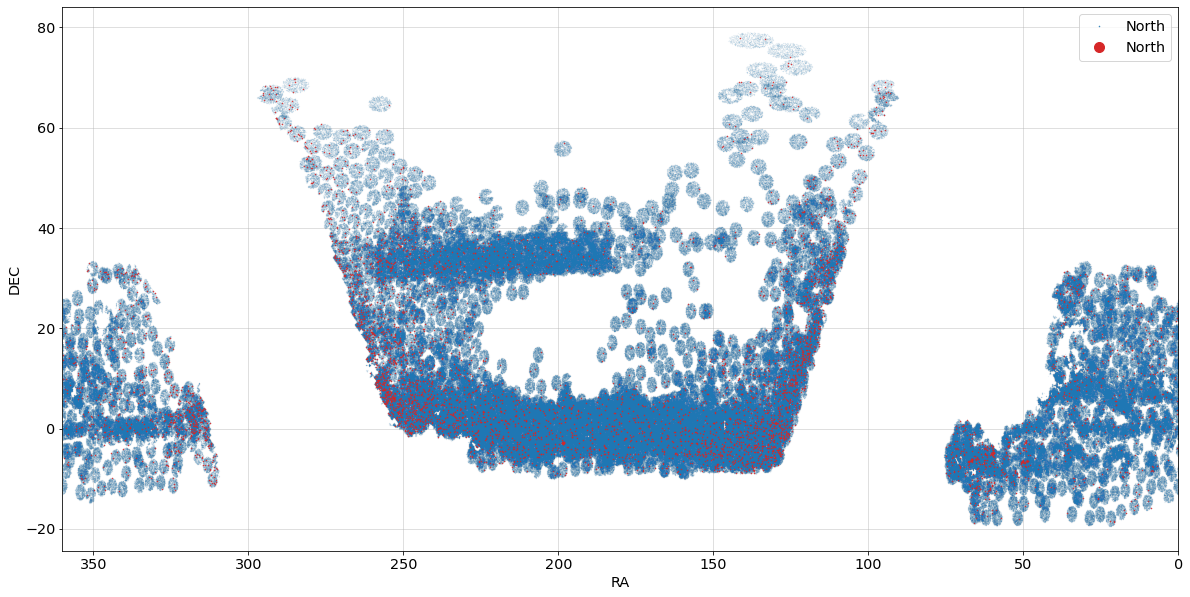

In [8]:
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)

plt.figure(figsize=(20, 10))
plt.plot(cat['RA'][~mask_star], cat['DEC'][~mask_star], 'C0.', ms=.05, label='North')
plt.plot(cat['RA'][mask_star], cat['DEC'][mask_star], 'C3.', ms=1, label='North')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.xlim(360, 0)
plt.show()

379987 1839937


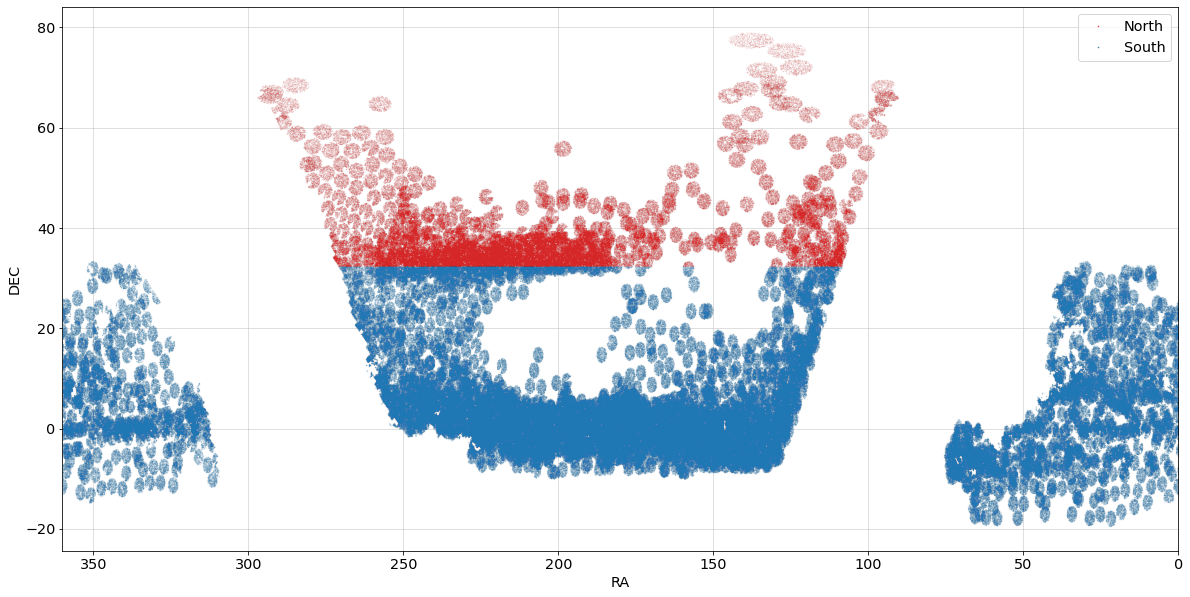

In [9]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

plt.figure(figsize=(20, 10))
plt.plot(cat['RA'][mask_north], cat['DEC'][mask_north], 'C3.', ms=.05, label='North')
plt.plot(cat['RA'][mask_south], cat['DEC'][mask_south], 'C0.', ms=.05, label='South')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.xlim(360, 0)
plt.show()

In [10]:
# numbers from target_densities_and_qso_fractions.ipynb

densities = {'all_south': 601.5217235484873,
             'all_north': 603.4400744908448,
             'bin_1_south': 80.73076914722965,
             'bin_1_north': 83.6073237937275,
             'bin_2_south': 147.34825745628333,
             'bin_2_north': 150.26678405791858,
             'bin_3_south': 164.06149883036238,
             'bin_3_north': 163.39069686671507,
             'bin_4_south': 149.2404289122462,
             'bin_4_north': 149.94562916498495}

qso_fractions = {'S1': 0.00354157666129437,
                 'S2': 0.006384602682681207,
                 'S3': 0.009656279477716915,
                 'S4': 0.004518003793807739,
                 'N1': 0.004999559947875116,
                 'N2': 0.007013531060148927,
                 'N3': 0.007398830830737762,
                 'N4': 0.00322141998926721}

In [11]:
area_south = np.sum(mask_south)/densities['all_south']
print(area_south)

area_north = np.sum(mask_north)/densities['all_north']
print(area_north)

3058.8039100996602
629.7013010291298


--------
# Weights

In [12]:
cat['spec_weight'] = 1.

mask_qso = cat['DESI_TARGET'] & 2**2>0
print(np.sum(mask_qso), np.sum(mask_qso)/len(mask_qso))

# QSO weights
for photsys in ['S', 'N']:
    for bin_index in range(1, 5):
        mask0 = cat['PHOTSYS']==photsys
        mask0 &= cat['pz_bin']==bin_index
        mask = mask0 & mask_qso
        qso_weight = qso_fractions[photsys+str(bin_index)] / (np.sum(mask)/np.sum(mask0))
        print(bin_index, np.sum(mask)/np.sum(mask0), qso_weight)
        cat['spec_weight'][mask] *= qso_weight

18975 0.008547589917492672
1 0.0038249094256696562 0.9259243205933743
2 0.008802078595217545 0.7253517011482002
3 0.011524293664167073 0.8379064052959319
4 0.004362156303227376 1.0357271678837041
1 0.004984123929567978 1.0030970374182642
2 0.00852530382731725 0.822672270948958
3 0.009567741368020875 0.7733100787472728
4 0.005041838788263955 0.6389375235015069


In [13]:
# Zero weight for stars
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
print('Star fraction: {:.3f}%'.format(np.sum(mask_star)/len(mask_star)*100))
for pz_bin in range(1, 5):
    mask0 = (cat['pz_bin']==pz_bin)
    print('bin {}: {:.3f}%'.format(pz_bin, np.sum(mask0 & mask_star)/np.sum(mask0)*100))
cat['spec_weight'][mask_star] = 0

Star fraction: 0.270%
bin 1: 0.142%
bin 2: 0.158%
bin 3: 0.194%
bin 4: 0.364%


-0.29940119760479045 0.02727544910179641 0.0228


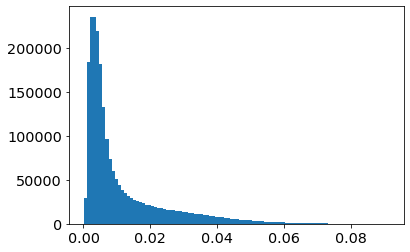

In [14]:
def failure_rate(flux, efftime, a0, a1, a2):
    sn = flux * np.sqrt(efftime)
    return np.clip(np.exp(a0*sn+a1)+a2/flux, 0, 1)

# Use the coefficients from the LRG target selection paper
coeffs = [-0.0911, 3.34, 0.0228]  # Main+SV3

a0, a1, a2 = -1/coeffs[1], -coeffs[0]/coeffs[1], coeffs[2]
print(a0, a1, a2)

cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']
cat['FIBERFLUX_Z_EC'] = cat['FIBERFLUX_Z']*10**(0.4*1.211*cat['EBV'])
cat['fail_prob'] = failure_rate(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *coeffs)

plt.hist(cat['fail_prob'], 100)
plt.show()

cat['spec_weight'] /= (1-cat['fail_prob'])

In [15]:
# Renormalize the spectro weights to the total density
# so it puts the "full" sample on the same weight scale as the binned subsamples
mask = mask_north.copy()
renorm_factor = densities['all_north'] / np.sum(cat['spec_weight'][mask])
cat['spec_weight'][mask] = cat['spec_weight'][mask] * renorm_factor
print('north', np.sum(cat['spec_weight'][mask]))

mask = mask_south.copy()
renorm_factor = densities['all_south'] / np.sum(cat['spec_weight'][mask])
cat['spec_weight'][mask] = cat['spec_weight'][mask] * renorm_factor
print('South', np.sum(cat['spec_weight'][mask]))

north 603.4400744908447
South 601.5217235484872


In [16]:
# Combine spectroscopic and imaging weights
cat['weight'] = cat['spec_weight'] * cat['imaging_weight']

In [17]:
# Renormalize the weights to the total density (targets per sq. deg.)
for field in ['north', 'south']:
    if field=='north':
        mask_field = mask_north.copy()
    elif field=='south':
        mask_field = mask_south.copy()
    else:
        raise ValueError()
    for pz_bin in range(1, 5):
        mask = mask_field & (cat['pz_bin']==pz_bin)
        renorm_factor = densities['bin_{}_{}'.format(pz_bin, field)] / np.sum(cat['weight'][mask])
        cat['weight'][mask] = cat['weight'][mask] * renorm_factor
        print('{}_{}'.format(field, pz_bin), np.sum(cat['weight'][mask]))

north_1 83.6073237937275
north_2 150.26678405791858
north_3 163.39069686671505
north_4 149.94562916498495
south_1 80.73076914722967
south_2 147.34825745628333
south_3 164.06149883036244
south_4 149.24042891224622


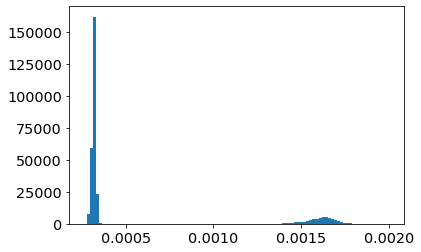

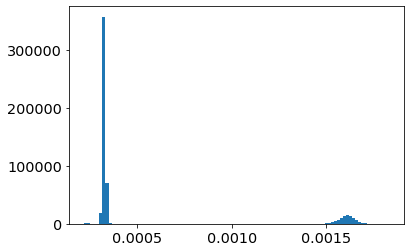

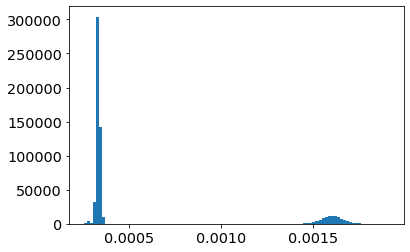

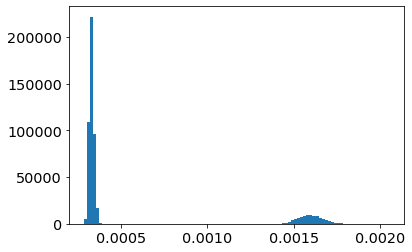

In [18]:
mask = cat['weight']!=0
mask &= cat['pz_bin']!=-1

for pz_bin in range(1, 5):
    mask1 = mask & (cat['pz_bin']==pz_bin)
    plt.hist(cat['weight'][mask1], 100)
    plt.show()

--------

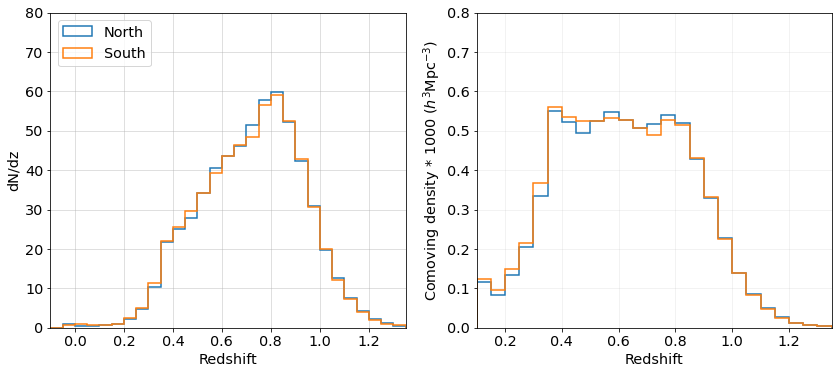

In [19]:
# No spectro weights

bins = np.arange(-0.1, 1.45, 0.05)
bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north], weights=np.full(np.sum(mask_north), np.mean(cat['spec_weight'][mask_north])),
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south], weights=np.full(np.sum(mask_south), np.mean(cat['spec_weight'][mask_south])),
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.35)
axes[0].set_ylim(0, 80)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

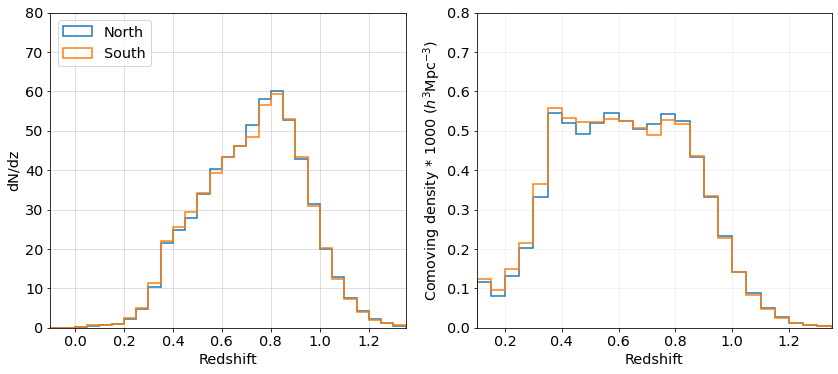

In [20]:
# With spectro weights

bins = np.arange(-0.1, 1.45, 0.05)
bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north], weights=cat['spec_weight'][mask_north],
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south], weights=cat['spec_weight'][mask_south],
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.35)
axes[0].set_ylim(0, 80)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, weights=cat['spec_weight'][mask_north]/np.mean(cat['spec_weight'][mask_north]), zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, weights=cat['spec_weight'][mask_south]/np.mean(cat['spec_weight'][mask_south]), zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

In [21]:
print('stellar fraction: {:.2f}%\n'.format(100*np.sum(mask_star)/len(mask_star)))

print('South:\n')
mask_all = mask_south & (cat['pz_bin']!=-1)
for pz_bin in range(1, 5):
    mask = mask_south & (cat['pz_bin']==pz_bin)
    print('bin {} fraction: {:.4f}'.format(pz_bin, np.sum(mask)/np.sum(mask_all)))
    # print(np.percentile(cat['Z'][mask], [2, 16, 50, 84, 98]))
    print('mean redshift: {:.3f}'.format(np.median(cat['Z'][mask])))
#     print('1-sigma width: {:.3f};   2-sigma width: {:.3f}'.format(np.percentile(cat['Z'][mask], 84)-np.percentile(cat['Z'][mask], 16),
#         np.percentile(cat['Z'][mask], 98)-np.percentile(cat['Z'][mask], 2)))
    print('nmad: {:.3f}'.format(nmad(cat['Z'][mask])))
    print('stellar fraction: {:.2f}%'.format(100*np.sum(mask_star & mask)/np.sum(mask)))
    print()

print()

print('North:\n')
mask_all = mask_north & (cat['pz_bin']!=-1)
for pz_bin in range(1, 5):
    mask = mask_north & (cat['pz_bin']==pz_bin)
    print('bin {} fraction: {:.4f}'.format(pz_bin, np.sum(mask)/np.sum(mask_all)))
    # print(np.percentile(cat['Z'][mask], [2, 16, 50, 84, 98]))
    print('mean redshift: {:.3f}'.format(np.median(cat['Z'][mask])))
#     print('1-sigma width: {:.3f};   2-sigma width: {:.3f}'.format(np.percentile(cat['Z'][mask], 84)-np.percentile(cat['Z'][mask], 16),
#         np.percentile(cat['Z'][mask], 98)-np.percentile(cat['Z'][mask], 2)))
    print('nmad: {:.3f}'.format(nmad(cat['Z'][mask])))
    print('stellar fraction: {:.2f}%'.format(100*np.sum(mask_star & mask)/np.sum(mask)))
    print()

stellar fraction: 0.27%

South:

bin 1 fraction: 0.1531
mean redshift: 0.473
nmad: 0.059
stellar fraction: 0.13%

bin 2 fraction: 0.2732
mean redshift: 0.628
nmad: 0.069
stellar fraction: 0.17%

bin 3 fraction: 0.2997
mean redshift: 0.788
nmad: 0.067
stellar fraction: 0.20%

bin 4 fraction: 0.2740
mean redshift: 0.920
nmad: 0.085
stellar fraction: 0.38%


North:

bin 1 fraction: 0.1518
mean redshift: 0.474
nmad: 0.061
stellar fraction: 0.22%

bin 2 fraction: 0.2737
mean redshift: 0.629
nmad: 0.070
stellar fraction: 0.08%

bin 3 fraction: 0.2988
mean redshift: 0.789
nmad: 0.068
stellar fraction: 0.14%

bin 4 fraction: 0.2757
mean redshift: 0.919
nmad: 0.086
stellar fraction: 0.31%



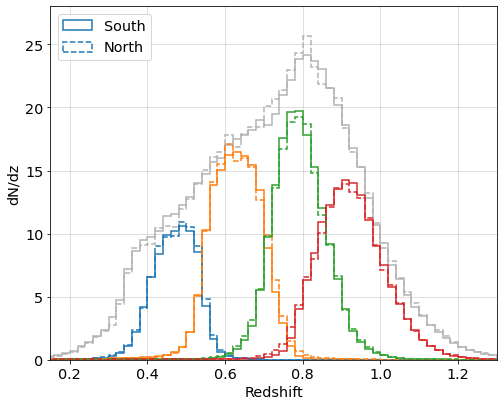

In [22]:
bins = np.arange(-0.1, 1.45, 0.02)
bin_centers = (bins[1:]+bins[:-1])/2

fig, ax = plt.subplots(figsize=(8, 6.5))

mask = mask_south.copy()
ax.hist(cat['Z'][mask], weights=cat['spec_weight'][mask],
             bins=bins, lw=1.5, histtype='step', color='0.7')
mask = mask_north.copy()
ax.hist(cat['Z'][mask], weights=cat['spec_weight'][mask],
             bins=bins, lw=1.5, histtype='step', color='0.7', ls='--')

for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'South'
    else:
        label = None
    mask = mask_south & (cat['pz_bin']==pz_bin)
    ax.hist(cat['Z'][mask], weights=cat['weight'][mask],
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(pz_bin-1))
for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'North'
    else:
        label = None
    mask = mask_north & (cat['pz_bin']==pz_bin)
    ax.hist(cat['Z'][mask], weights=cat['weight'][mask],
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(pz_bin-1), ls='--')

ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.15, 1.3)
ax.set_ylim(0, 28)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
plt.show()

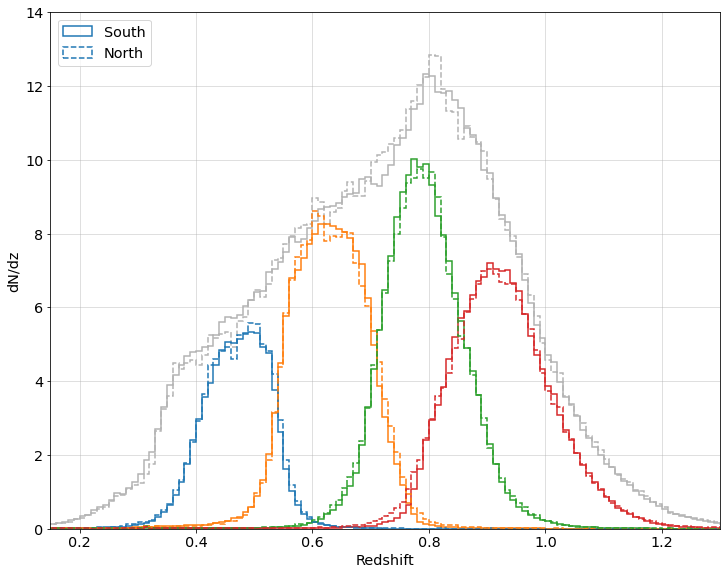

In [23]:
bins = np.arange(-0.1, 1.45, 0.01)
bin_centers = (bins[1:]+bins[:-1])/2

fig, ax = plt.subplots(figsize=(12, 9.5))

mask = mask_south.copy()
ax.hist(cat['Z'][mask], weights=cat['spec_weight'][mask],
             bins=bins, lw=1.5, histtype='step', color='0.7')
mask = mask_north.copy()
ax.hist(cat['Z'][mask], weights=cat['spec_weight'][mask],
             bins=bins, lw=1.5, histtype='step', color='0.7', ls='--')

for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'South'
    else:
        label = None
    mask = mask_south & (cat['pz_bin']==pz_bin)
    ax.hist(cat['Z'][mask], weights=cat['weight'][mask],
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(pz_bin-1))
for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'North'
    else:
        label = None
    mask = mask_north & (cat['pz_bin']==pz_bin)
    ax.hist(cat['Z'][mask], weights=cat['weight'][mask],
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(pz_bin-1), ls='--')

ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.15, 1.3)
ax.set_ylim(0, 14)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
plt.show()

In [24]:
bins = np.round(np.arange(0., 1.5, 0.02), 2)

t = Table()
t['zmin'] = bins[:-1]
t['zmax'] = bins[1:]

for pz_bin in range(0, 5):
    if pz_bin==0:
        mask = mask_north.copy()
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['spec_weight'][mask])[0]
        t['all_north'] = surf_density
        t['all_north'].format = '%.3f'
    else:
        mask = mask_north & (cat['pz_bin']==pz_bin)
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['weight'][mask])[0]
        t['bin_{}_north'.format(pz_bin)] = surf_density
        t['bin_{}_north'.format(pz_bin)].format = '%.3f'

for pz_bin in range(0, 5):
    if pz_bin==0:
        mask = mask_south.copy()
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['spec_weight'][mask])[0]
        t['all_south'] = surf_density
        t['all_south'].format = '%.3f'
    else:
        mask = mask_south & (cat['pz_bin']==pz_bin)
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['weight'][mask])[0]
        t['bin_{}_south'.format(pz_bin)] = surf_density
        t['bin_{}_south'.format(pz_bin)].format = '%.3f'
    
t.write('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/dndz/daily_v0.1/main_lrg_pz_dndz_daily_v0.1_dz_0.02.txt', format='ascii.commented_header', overwrite=True)

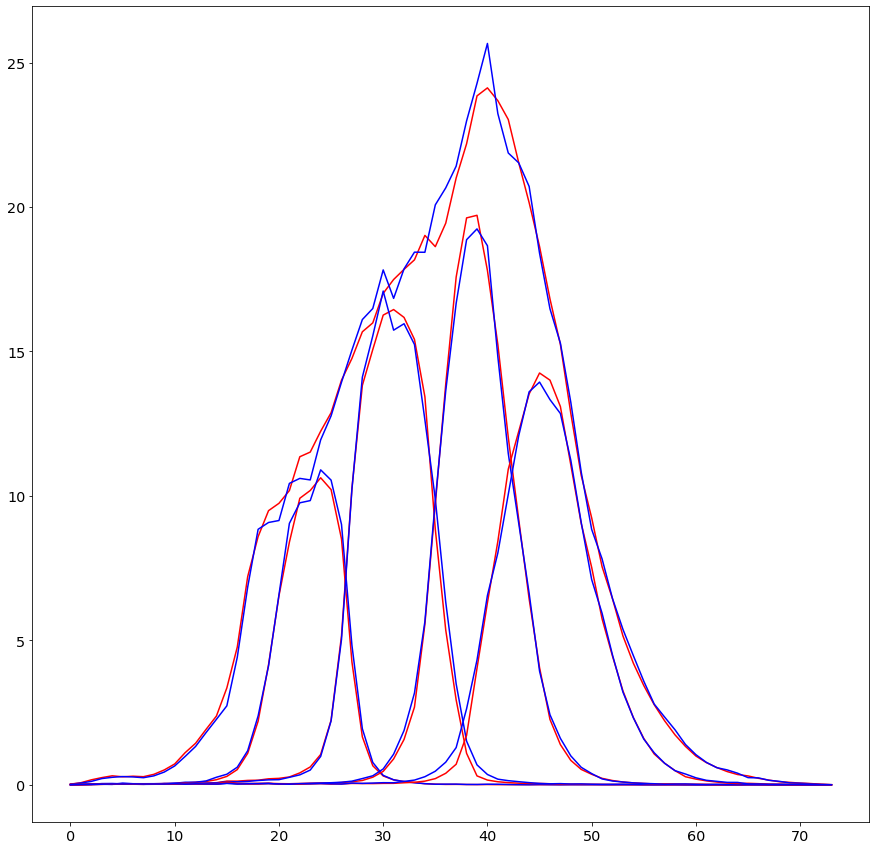

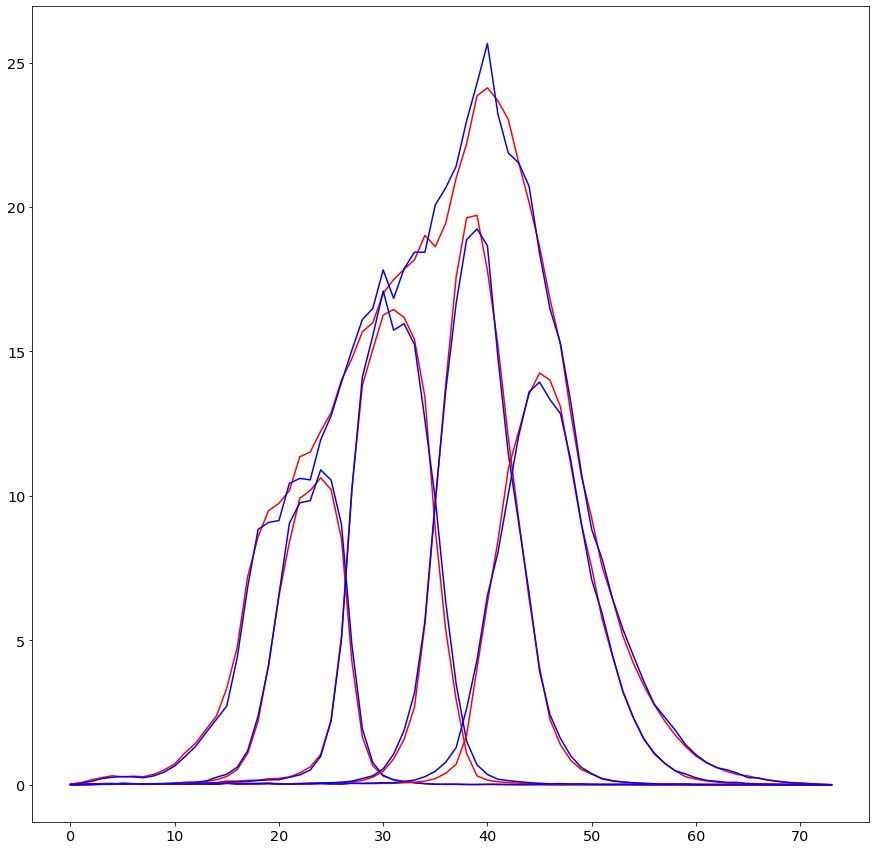

In [25]:
plt.figure(figsize=(15, 15))
plt.plot(t['all_south'], color='r')
plt.plot(t['all_north'], color='b')
for pz_bin in range(1, 5):
    plt.plot(t['bin_{}_south'.format(pz_bin)], color='r')
    plt.plot(t['bin_{}_north'.format(pz_bin)], color='b')
plt.show()

tt = Table.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/dndz/daily_v0.1/main_lrg_pz_dndz_daily_v0.1_dz_0.02.txt', format='ascii.commented_header')
plt.figure(figsize=(15, 15))
plt.plot(tt['all_south'], color='r')
plt.plot(tt['all_north'], color='b')
for pz_bin in range(1, 5):
    plt.plot(tt['bin_{}_south'.format(pz_bin)], color='r')
    plt.plot(tt['bin_{}_north'.format(pz_bin)], color='b')
plt.show()

In [26]:
bins = np.round(np.arange(0., 1.5, 0.01), 2)

t = Table()
t['zmin'] = bins[:-1]
t['zmax'] = bins[1:]

for pz_bin in range(0, 5):
    if pz_bin==0:
        mask = mask_north.copy()
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['spec_weight'][mask])[0]
        t['all_north'] = surf_density
        t['all_north'].format = '%.3f'
    else:
        mask = mask_north & (cat['pz_bin']==pz_bin)
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['weight'][mask])[0]
        t['bin_{}_north'.format(pz_bin)] = surf_density
        t['bin_{}_north'.format(pz_bin)].format = '%.3f'

for pz_bin in range(0, 5):
    if pz_bin==0:
        mask = mask_south.copy()
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['spec_weight'][mask])[0]
        t['all_south'] = surf_density
        t['all_south'].format = '%.3f'
    else:
        mask = mask_south & (cat['pz_bin']==pz_bin)
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['weight'][mask])[0]
        t['bin_{}_south'.format(pz_bin)] = surf_density
        t['bin_{}_south'.format(pz_bin)].format = '%.3f'
    
t.write('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/dndz/daily_v0.1/main_lrg_pz_dndz_daily_v0.1_dz_0.01.txt', format='ascii.commented_header', overwrite=True)

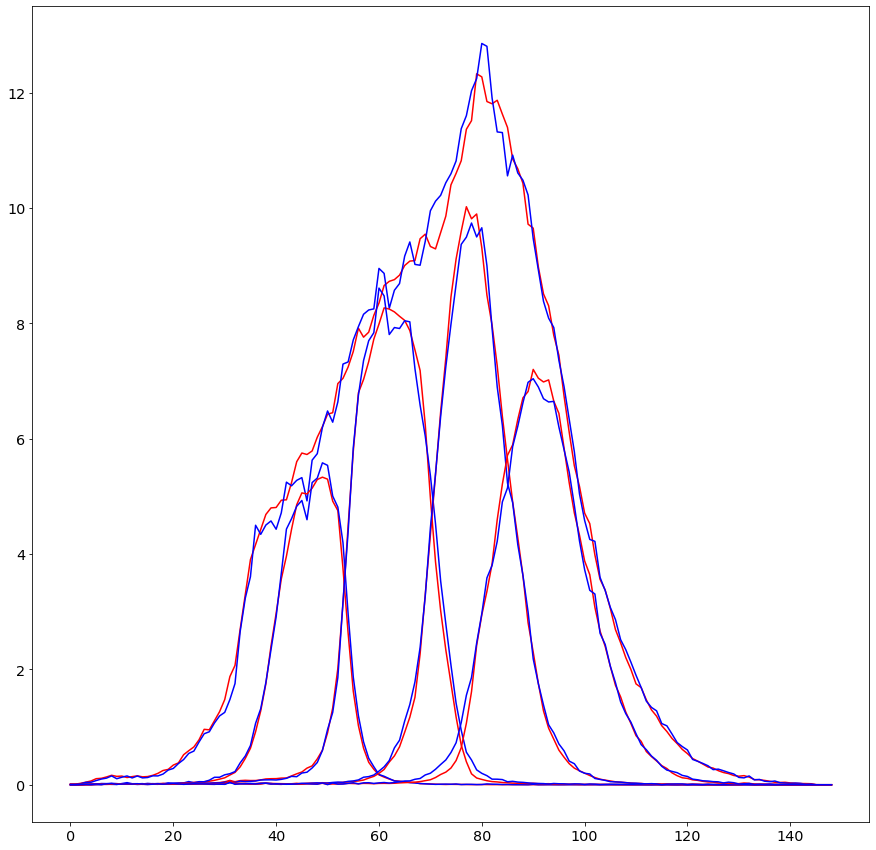

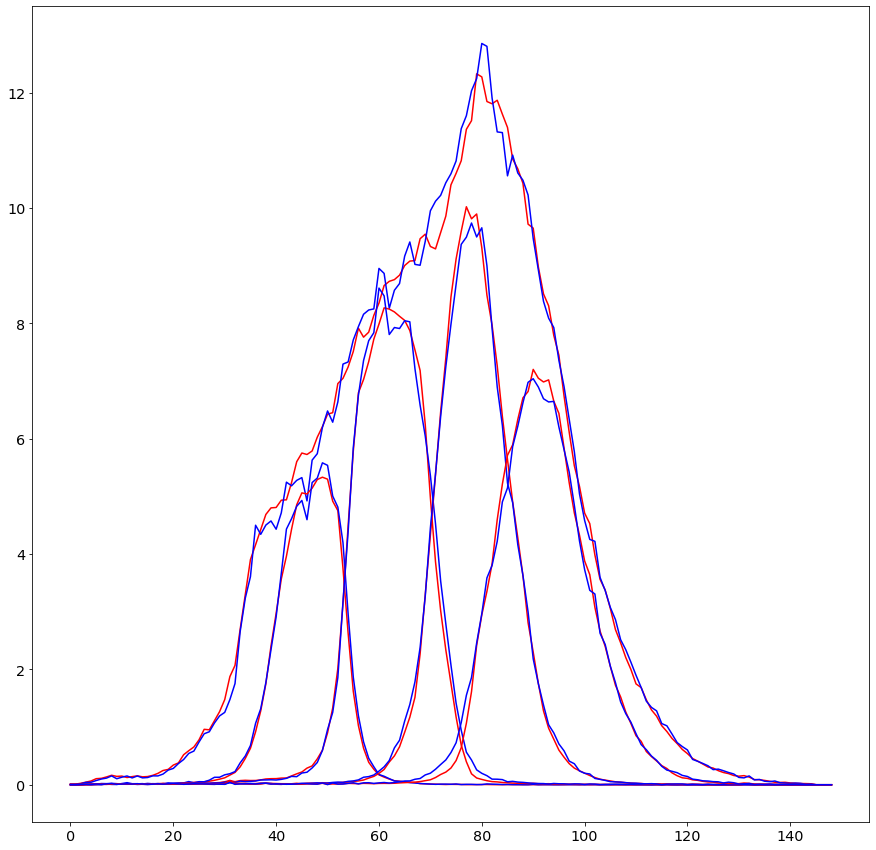

In [27]:
plt.figure(figsize=(15, 15))
plt.plot(t['all_south'], color='r')
plt.plot(t['all_north'], color='b')
for pz_bin in range(1, 5):
    plt.plot(t['bin_{}_south'.format(pz_bin)], color='r')
    plt.plot(t['bin_{}_north'.format(pz_bin)], color='b')
plt.show()

tt = Table.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/dndz/daily_v0.1/main_lrg_pz_dndz_daily_v0.1_dz_0.01.txt', format='ascii.commented_header')
plt.figure(figsize=(15, 15))
plt.plot(tt['all_south'], color='r')
plt.plot(tt['all_north'], color='b')
for pz_bin in range(1, 5):
    plt.plot(tt['bin_{}_south'.format(pz_bin)], color='r')
    plt.plot(tt['bin_{}_north'.format(pz_bin)], color='b')
plt.show()